In [1]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
#Load Data
df = pd.read_csv('Loan_Default.csv')

#Drop rows where 'age' and 'Status" are missing
df = df.dropna(subset=['age', 'Status'])

--- TESTING HYPOTHESIS ---
Default Rate (Under 35): 22.63%
Default Rate (35 & Over): 24.85%


/var/folders/00/78x9_z0j2hz7zwrr0nhhc44c0000gn/T/ipykernel_5735/3307758709.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hypothesis_results.index, y=hypothesis_results.values, palette='Reds_r')


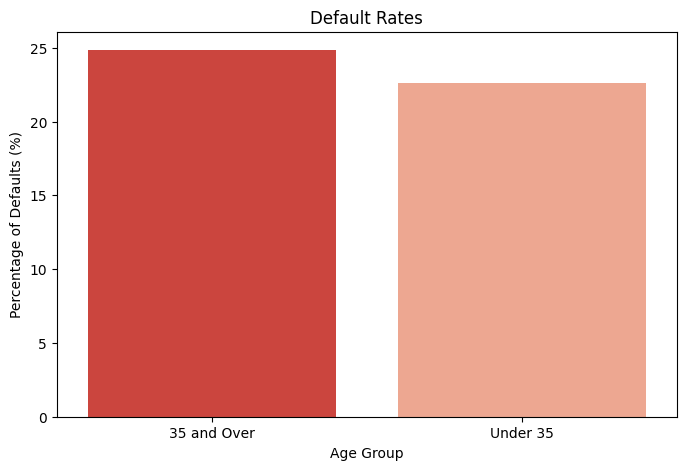

In [5]:
#Testing Hypothesis
print("--- TESTING HYPOTHESIS ---")

def age_range(age_val):
    young_group = ['<25', '25-34']
    if age_val in young_group:
        return 'Under 35'
    else:
        return '35 and Over'
df['age_group'] = df['age'].apply(age_range)

#Calculate the mean of 'Status' (1 = Default, 0 = Repay)
hypothesis_results = df.groupby('age_group')['Status'].mean() * 100

#Percentage
print(f"Default Rate (Under 35): {hypothesis_results['Under 35']:.2f}%")
print(f"Default Rate (35 & Over): {hypothesis_results['35 and Over']:.2f}%")

# Bar Graph
plt.figure(figsize=(8, 5))
sns.barplot(x=hypothesis_results.index, y=hypothesis_results.values, palette='Reds_r')
plt.title('Default Rates')
plt.ylabel('Percentage of Defaults (%)')
plt.xlabel('Age Group')
plt.show()

In [6]:
#Data Preprocessing

#Drop columns 
cols_to_drop = ['ID', 'year', 'age_group']

X = df.drop(['Status'] + cols_to_drop, axis=1)
y = df['Status']

# Handle Categorical variables
X = pd.get_dummies(X, drop_first=True)

# Handle Missing Values in features
X = X.fillna(X.median())

# Train-Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


==================== Logistic Regression ====================
Accuracy: 0.8738
              precision    recall  f1-score   support

           0       0.87      0.99      0.92     22521
           1       0.93      0.52      0.66      7173

    accuracy                           0.87     29694
   macro avg       0.90      0.75      0.79     29694
weighted avg       0.88      0.87      0.86     29694



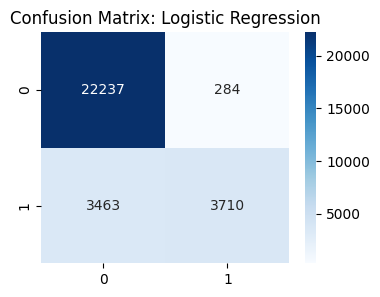


==================== Random Forest ====================
Accuracy: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22521
           1       1.00      1.00      1.00      7173

    accuracy                           1.00     29694
   macro avg       1.00      1.00      1.00     29694
weighted avg       1.00      1.00      1.00     29694


Top 5 Predictive Features:
Interest_rate_spread    0.291599
Upfront_charges         0.243191
rate_of_interest        0.167857
credit_type_EQUI        0.131385
property_value          0.034255
dtype: float64


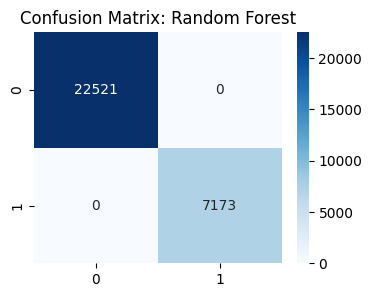

In [7]:
#Model Training

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    print(f"\n{'='*20} {name} {'='*20}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred))
    
    #Random Forest
    if name == "Random Forest":
        importances = model.feature_importances_
        feat_importances = pd.Series(importances, index=X.columns)
        print("\nTop 5 Predictive Features:")
        print(feat_importances.nlargest(5))

    #Confusion Matrix Heatmap
    plt.figure(figsize=(4,3))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {name}')
    plt.show()